X_test : (219, 106) | y_test : (219,)
Modèles chargés : ['XGBoost', 'LightGBM', 'RandomForest', 'LogisticRegression']


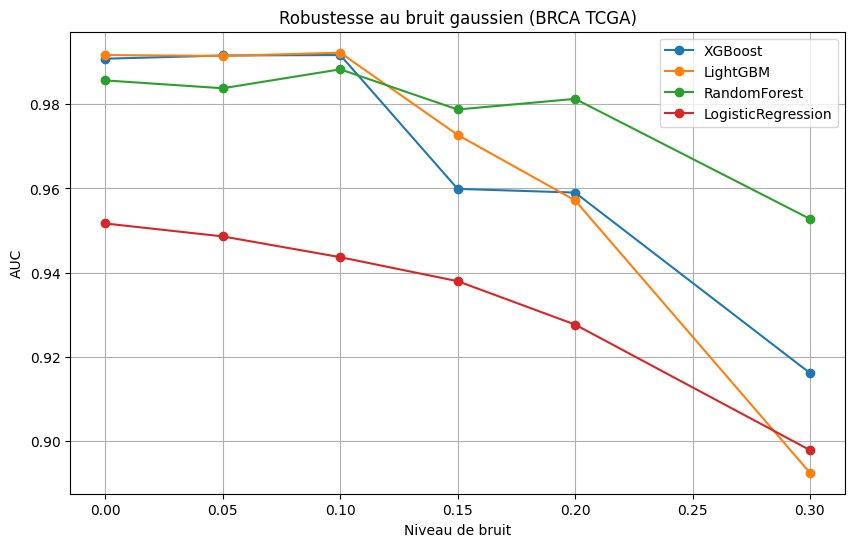

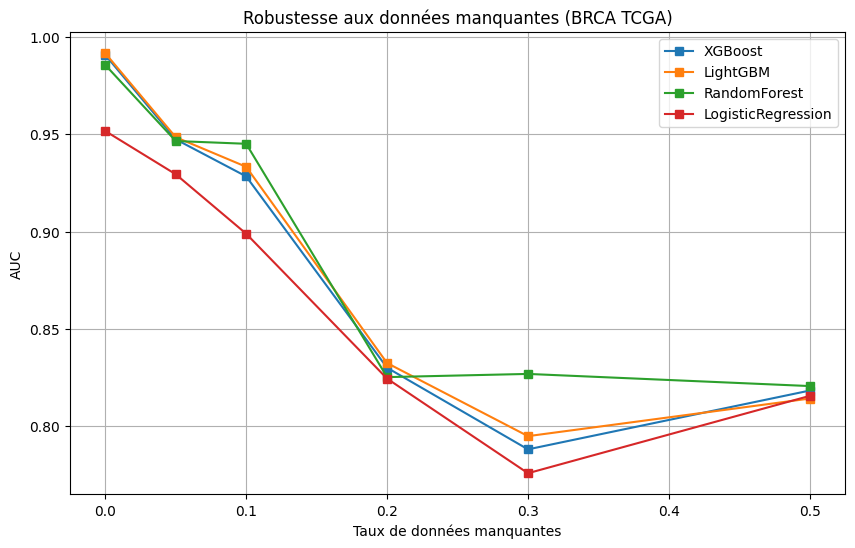


🏥 Validation clinique:
1. Âge moyen par groupe:
Complication
0    0.000983
1    0.269575
Name: Age, dtype: float64

2. Corrélation avec le stade tumoral:
Stage
-1.788946    0.000000
-1.410365    0.000000
-1.031784    0.000000
-0.653203    0.000000
-0.274623    0.016949
 0.103958    0.000000
 0.482539    1.000000
 0.861120    1.000000
 1.239701    1.000000
 1.618281    1.000000
 1.996862    1.000000
 2.375443    0.000000
 2.754024    0.000000
Name: Complication, dtype: float64

✅ Validation terminée!


In [1]:
# Cellule 1 : Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from pathlib import Path
import joblib
import sys

# Chemins
project_root = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction')
sys.path.append(str(project_root / 'src'))

PROCESSED_DIR = project_root / 'data' / 'processed'
RESULTS_DIR   = project_root / 'results'
MODELS_DIR    = project_root / 'models'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Cellule 2 : Chargement
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

models = {
    'XGBoost':           joblib.load(MODELS_DIR / 'xgboost_brca.pkl'),
    'LightGBM':          joblib.load(MODELS_DIR / 'lightgbm_brca.pkl'),
    'RandomForest':      joblib.load(MODELS_DIR / 'randomforest_brca.pkl'),
    'LogisticRegression':joblib.load(MODELS_DIR / 'logisticregression_brca.pkl')
}

print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")
print(f"Modèles chargés : {list(models.keys())}")

# Cellule 3 : Test de robustesse - Bruit gaussien
def add_noise(X, noise_level=0.1):
    noise = np.random.normal(0, noise_level * X.std(), X.shape)
    return X + noise

noise_levels      = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
robustness_results = {name: [] for name in models.keys()}

for noise in noise_levels:
    X_noisy = add_noise(X_test, noise)
    for name, model in models.items():
        y_proba = model.predict_proba(X_noisy)[:, 1]
        auc     = roc_auc_score(y_test, y_proba)
        robustness_results[name].append(auc)

plt.figure(figsize=(10, 6))
for name, aucs in robustness_results.items():
    plt.plot(noise_levels, aucs, marker='o', label=name)
plt.xlabel('Niveau de bruit')
plt.ylabel('AUC')
plt.title('Robustesse au bruit gaussien (BRCA TCGA)')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR / 'robustness_noise.png', dpi=300)
plt.show()

# Cellule 4 : Test de robustesse - Données manquantes
def add_missing(X, missing_rate=0.1):
    X_missing = X.copy()
    mask      = np.random.random(X.shape) < missing_rate
    X_missing[mask] = np.nan
    return X_missing.fillna(X_missing.mean())

missing_rates   = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
missing_results = {name: [] for name in models.keys()}

for rate in missing_rates:
    X_missing = add_missing(X_test, rate)
    for name, model in models.items():
        y_proba = model.predict_proba(X_missing)[:, 1]
        auc     = roc_auc_score(y_test, y_proba)
        missing_results[name].append(auc)

plt.figure(figsize=(10, 6))
for name, aucs in missing_results.items():
    plt.plot(missing_rates, aucs, marker='s', label=name)
plt.xlabel('Taux de données manquantes')
plt.ylabel('AUC')
plt.title('Robustesse aux données manquantes (BRCA TCGA)')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR / 'robustness_missing.png', dpi=300)
plt.show()

# Cellule 5 : Validation clinique — noms de colonnes corrigés
print("\n🏥 Validation clinique:")

print("1. Âge moyen par groupe:")
print(pd.DataFrame({'Age': X_test['AGE'], 'Complication': y_test})
        .groupby('Complication')['Age'].mean())

print("\n2. Corrélation avec le stade tumoral:")
print(pd.DataFrame({'Stage': X_test['TUMOR_STAGE_ENC'], 'Complication': y_test})
        .groupby('Stage')['Complication'].mean())

print("\n✅ Validation terminée!")